In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from ensemble_model import EnsembleModel
import joblib

## 1. Load the Dataset

The Dataset contains one row per completed match.

Each row contains:
- the final match outcome('team0_won')
- aggreagted statistics for both teams
- statistics for each of the six players on each team
- hero an lane assignment

Statistics measured at the 5-minute snapshot.

## 2. Feature Engineering

The engineered features fall into several groups:

### Team compositions and distributions
- Carry share
- Networth standart deviation
- Richest player relative to team avarage

### Team performance
- Team kill/death ratio (KDR)

### Team-to-team differences
- Networth difference
- Damage difference
- Avarage level difference
- Carry networth difference
- KDR difference
- Gold-per-minute difference
- Objective damage difference

### Relative ratios
- Networth ratio
- Damage ratio
- Objective damage ratio

In [ ]:
df = pd.read_csv("YOUR_PATH_HERE")

new_features = pd.DataFrame({
    "team0_carry_share" : (df["team0_p1_networth"]/df["team0_team_total_networth"]),
    "team1_carry_share" : (df["team1_p1_networth"]/df["team1_team_total_networth"]),
    "team0_networth_std" : df[["team0_p1_networth","team0_p2_networth","team0_p3_networth","team0_p4_networth","team0_p5_networth","team0_p6_networth"]].std(axis=1),
    "team1_networth_std" : df[["team1_p1_networth","team1_p2_networth","team1_p3_networth","team1_p4_networth","team1_p5_networth","team1_p6_networth"]].std(axis=1),
    "team0_team_kdr" : (df["team0_team_total_kills"]/(df["team0_team_total_deaths"]+1)),
    "team1_team_kdr" : (df["team1_team_total_kills"]/(df["team1_team_total_deaths"]+1)),
    "team0_richest_vs_team_avg" : (df["team0_p1_networth"]/(df["team0_team_total_networth"]/6)),
    "team1_richest_vs_team_avg" : (df["team1_p1_networth"]/(df["team1_team_total_networth"]/6)),
    'networth_diff': df['team0_team_total_networth'] - df['team1_team_total_networth'],
    "damage_diff":df["team0_team_total_damage"]-df["team1_team_total_damage"],
    "level_diff":df["team0_team_avg_level"]-df["team1_team_avg_level"],
    "carry_diff":df["team0_p1_networth"] - df["team1_p1_networth"],
    "kdr_diff":(df["team0_team_total_kills"]/(df["team0_team_total_deaths"]+1))-(df["team1_team_total_kills"]/(df["team1_team_total_deaths"]+1)),
    "gpm_diff" : (df["team0_team_gold_per_minute"]-df["team1_team_gold_per_minute"]),
    "objective_diff" : (df["team0_team_total_objectivedamage"]-df["team1_team_total_objectivedamage"]),
    "networth_ratio" : (df["team0_team_total_networth"]/(df["team1_team_total_networth"]+1)),
    "damage_ratio" : (df["team0_team_total_damage"]/(df["team1_team_total_damage"]+1)),
    "objective_ratio" : (df["team0_team_total_objectivedamage"]/(df["team1_team_total_objectivedamage"]+1))
})
df = pd.concat([df, new_features],axis=1)
print(df.shape)
df


(15879, 202)


,match_id,team0_won,team0_team_total_kills,team0_team_total_deaths,team0_team_total_networth,team0_team_total_damage,team0_team_total_objectivedamage,team0_team_avg_level,team0_team_gold_per_minute,team0_p1_hero,...,networth_diff,damage_diff,level_diff,carry_diff,kdr_diff,gpm_diff,objective_diff,networth_ratio,damage_ratio,objective_ratio
0,1741000,1,48,35,166321,127231,25378,21.666667,924.005525,2,...,-5809,12291,-0.333333,-8964,0.666667,-32.272221,4141,0.966247,1.106924,1.194934
1,30579330,0,52,40,167923,138069,11407,27.666667,932.905524,1,...,-14839,-3235,-1.166667,-312,0.541020,-82.438886,-16737,0.918802,0.977099,0.405294
2,38763513,1,42,45,182109,133240,12265,25.000000,1011.716633,14,...,1060,-4281,0.000000,-4147,-0.020290,5.888889,241,1.005849,0.968863,1.019958
3,39165037,1,39,26,174473,118950,14057,23.500000,969.294412,2,...,20935,11239,0.833333,10347,0.849206,116.305552,-3880,1.136343,1.104334,0.783644
4,39162555,0,37,34,155575,125247,13086,22.666667,864.305527,13,...,-16115,15379,-1.500000,-1959,0.162406,-89.527775,-2172,0.906134,1.139967,0.857592
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15874,83271092,0,53,38,192125,168900,19792,30.000000,1067.361076,25,...,2644,23409,0.500000,-503,0.692308,14.688888,9799,1.013949,1.160889,1.980388
15875,83270763,0,13,48,149613,99825,12617,25.000000,831.183306,50,...,-85089,-62147,-9.333333,-13438,-2.734694,-472.716651,-43039,0.637457,0.616306,0.226692
15876,83270891,1,61,48,226895,229007,60751,33.500000,1260.527736,13,...,31979,12311,3.500000,5246,0.514739,177.661105,32915,1.164060,1.056807,2.182383
15877,83271419,0,30,44,167973,148589,14403,27.333333,933.183302,66,...,-15721,-16275,-1.333333,-715,-0.666667,-87.338886,-16241,0.914412,0.901277,0.469995


## 3. Train/Test Split

The data is split into 80% training and 20% test data

In [ ]:
X = df.drop(columns=["team0_won","match_id"])

y = df["team0_won"]

categorical_columns = []
for team in [0,1]:
    for i in range(1,7):
        categorical_columns.append(f'team{team}_p{i}_hero')
        categorical_columns.append(f'team{team}_p{i}_lane')

X = pd.get_dummies(X, columns=categorical_columns)
feature_columns = joblib.load("YOUR_PATH_HERE")
X = X.reindex(columns=feature_columns, fill_value=0)
print(X.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X.columns.to_list()

(15879, 679)


['team0_team_total_kills',
 'team0_team_total_deaths',
 'team0_team_total_networth',
 'team0_team_total_damage',
 'team0_team_total_objectivedamage',
 'team0_team_avg_level',
 'team0_team_gold_per_minute',
 'team0_p1_kills',
 'team0_p1_deaths',
 'team0_p1_assists',
 'team0_p1_networth',
 'team0_p1_damage',
 'team0_p1_creeps',
 'team0_p1_level',
 'team0_p1_objective_damage',
 'team0_p1_denies',
 'team0_p1_gold_per_minute',
 'team0_p1_player_healing',
 'team0_p1_self_healing',
 'team0_p2_kills',
 'team0_p2_deaths',
 'team0_p2_assists',
 'team0_p2_networth',
 'team0_p2_damage',
 'team0_p2_creeps',
 'team0_p2_level',
 'team0_p2_objective_damage',
 'team0_p2_denies',
 'team0_p2_gold_per_minute',
 'team0_p2_player_healing',
 'team0_p2_self_healing',
 'team0_p3_kills',
 'team0_p3_deaths',
 'team0_p3_assists',
 'team0_p3_networth',
 'team0_p3_damage',
 'team0_p3_creeps',
 'team0_p3_level',
 'team0_p3_objective_damage',
 'team0_p3_denies',
 'team0_p3_gold_per_minute',
 'team0_p3_player_healing'

## 4. Baseline Performance

As an initial benchmark, an XGB classifier and RandomForest classifier are trained with a relatively simple configurations.

The baseline models achive roughly 82% test accuracy

In [ ]:
model_xgb = XGBClassifier(n_estimators=300,max_depth=3,learning_rate=0.05,random_state=42)
model_xgb.fit(X_train, y_train)
predictions = model_xgb.predict(X_test)

accuracy_xgb = accuracy_score(y_test, predictions)
print(f"Accuracy for XGB: {accuracy_xgb}")
print("\nClassification Report:")
print(classification_report(y_test, predictions))

Accuracy for XGB: 0.8290302267002518

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.83      0.83      1580
           1       0.83      0.83      0.83      1596

    accuracy                           0.83      3176
   macro avg       0.83      0.83      0.83      3176
weighted avg       0.83      0.83      0.83      3176



In [5]:
importance = pd.DataFrame({"feature": X.columns, "importance": model_xgb.feature_importances_})

importance = importance.sort_values(by="importance",ascending=False)

importance

,feature,importance
166,networth_diff,0.156431
173,networth_ratio,0.122203
168,level_diff,0.016142
175,objective_ratio,0.012080
172,objective_diff,0.011626
...,...,...
649,team1_p6_hero_15,0.000000
650,team1_p6_hero_16,0.000000
651,team1_p6_hero_17,0.000000
652,team1_p6_hero_18,0.000000


In [ ]:
model_rf = RandomForestClassifier(n_estimators=300,max_depth=10,random_state=42)

model_rf.fit(X_train, y_train)

rf_predictions = model_rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)

print(f"Random Forest Accuracy: {rf_accuracy}")

print("\nRandom Forest Report:")

print(classification_report(y_test, rf_predictions))

Random Forest Accuracy: 0.8252518891687658

Random Forest Report:

              precision    recall  f1-score   support

           0       0.82      0.83      0.83      1580
           1       0.83      0.82      0.83      1596

    accuracy                           0.83      3176
   macro avg       0.83      0.83      0.83      3176
weighted avg       0.83      0.83      0.83      3176



In [7]:
rf_importance = pd.DataFrame({"feature": X.columns,"importance": model_rf.feature_importances_})

rf_importance = rf_importance.sort_values(by="importance",ascending=False)

print(rf_importance.head(20))

                        feature  importance
173              networth_ratio    0.069415
166               networth_diff    0.064600
168                  level_diff    0.054430
171                    gpm_diff    0.044544
172              objective_diff    0.031956
175             objective_ratio    0.028723
169                  carry_diff    0.025728
163              team1_team_kdr    0.021702
85   team1_team_gold_per_minute    0.020360
162              team0_team_kdr    0.019643
170                    kdr_diff    0.019545
2     team0_team_total_networth    0.018615
6    team0_team_gold_per_minute    0.017699
84         team1_team_avg_level    0.015682
58            team0_p5_networth    0.014493
81    team1_team_total_networth    0.013897
52     team0_p4_gold_per_minute    0.012836
64     team0_p5_gold_per_minute    0.010969
143    team1_p5_gold_per_minute    0.010956
101           team1_p2_networth    0.010811


## 5. Tuned XGBoost

The next experiment uses a more regularized XGBoost configuration.

In [8]:
model_xgb = XGBClassifier(

    n_estimators=500,

    max_depth=4,

    learning_rate=0.03,

    subsample=0.7,

    colsample_bytree=0.7,

    min_child_weight=7,

    gamma=2,

    reg_alpha=2,

    reg_lambda=10,

    random_state=42,
)
model_xgb.fit(X_train, y_train)
predictions = model_xgb.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy for XGB: {accuracy}")
print("\nClassification Report:\n")
print(classification_report(y_test, predictions))

Accuracy for XGB: 0.8261964735516373

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.82      0.82      1580
           1       0.83      0.83      0.83      1596

    accuracy                           0.83      3176
   macro avg       0.83      0.83      0.83      3176
weighted avg       0.83      0.83      0.83      3176



The tuned model achives ~82.6% test accuracy and ~87% train accuracy

In [ ]:
train_acc = model_xgb.score(X_train, y_train)

test_acc = model_xgb.score(X_test, y_test)

print(train_acc)
print(test_acc)

0.8697945367236086
0.8261964735516373


### 6. ROC-AUC

Because the final application outputs a win probability rather than only a binary prediction, accuracy alone is not sufficient.

ROC-AUC measures how well the model ranks winning teams above losing teams across different probability thresholds.

For the tuned XGBoost model, the test ROC-AUC is approximately 0.911.

In [ ]:
from sklearn.metrics import roc_auc_score

probs=model_xgb.predict_proba(X_test)[:,1]

print(roc_auc_score(y_test,probs))

0.9119182449795374


## 7. CatBoost

CatBoost is evaluated as a second gradient-boosting model.

It recieves approximately 83.4% test accuracy and 0.914 ROC-AUC score.

In [ ]:
model_cat = CatBoostClassifier(

    iterations=1500,

    depth=4,

    learning_rate=0.02,

    l2_leaf_reg=15,

    min_data_in_leaf=30,

    random_strength=5,

    bagging_temperature=2,

    verbose=100,

    random_seed=42
)

model_cat.fit(X_train, y_train)

probs = model_cat.predict_proba(X_test)[:,1]

predictions = model_cat.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy for CAT: {accuracy}")
print("\nClassification Report:")
print(classification_report(y_test, predictions))

pred=(probs>0.5)

print(accuracy_score(y_test, pred))

print(roc_auc_score(y_test, probs))

0:	learn: 0.6816922	total: 144ms	remaining: 3m 36s
100:	learn: 0.3993478	total: 864ms	remaining: 12s
200:	learn: 0.3794929	total: 1.59s	remaining: 10.3s
300:	learn: 0.3735499	total: 2.33s	remaining: 9.28s
400:	learn: 0.3696513	total: 3.05s	remaining: 8.36s
500:	learn: 0.3655631	total: 3.8s	remaining: 7.58s
600:	learn: 0.3589230	total: 4.51s	remaining: 6.74s
700:	learn: 0.3507795	total: 5.24s	remaining: 5.97s
800:	learn: 0.3440263	total: 5.97s	remaining: 5.21s
900:	learn: 0.3373724	total: 6.69s	remaining: 4.45s
1000:	learn: 0.3312137	total: 7.39s	remaining: 3.69s
1100:	learn: 0.3257057	total: 8.11s	remaining: 2.94s
1200:	learn: 0.3203394	total: 8.82s	remaining: 2.2s
1300:	learn: 0.3148369	total: 9.55s	remaining: 1.46s
1400:	learn: 0.3100221	total: 10.2s	remaining: 722ms
1499:	learn: 0.3051269	total: 10.9s	remaining: 0us
Accuracy for CAT: 0.8340680100755667

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.84      0.83      158

In [ ]:
train_acc = model_cat.score(X_train, y_train)

test_acc = model_cat.score(X_test, y_test)

print(train_acc)
print(test_acc)

0.8668031173738487
0.8340680100755667


## 8. Ensemble Model

The final predictor combines the XGBoost and CatBoost models using simple soft-voting ensemble. For each match, both models produce class probabilities, which are then avaraged using arithmetic mean.

On the test set ensemble achieves approxiamtely 82.9% accuracy and 0.913 ROC-AUC score.

In [ ]:
ensemble = EnsembleModel(model_xgb, model_cat)
joblib.dump(ensemble, 'YOUR_PATH_HERE')

pred = ensemble.predict(X_test)
probs = ensemble.predict_proba(X_test)

from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score

print(accuracy_score(y_test, pred))

print(roc_auc_score(y_test, probs[:, 1]))

0.8287153652392947
0.9136167158402335


## 9. Calibration Curve

A calibration curve compares predicted probabilities with the observed frequency of the positive class.

In [ ]:
from sklearn.calibration import CalibratedClassifierCV

calibrated = CalibratedClassifierCV(model_xgb, method='isotonic', cv=5)

calibrated.fit(X_train, y_train)

probs = calibrated.predict_proba(X_test)[:,1]

print(roc_auc_score( y_test, probs))

0.912736945211129


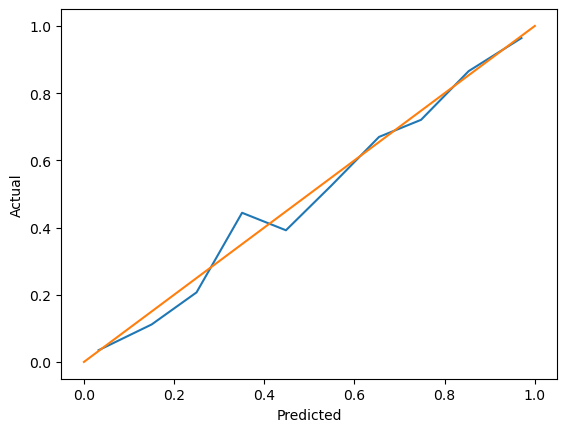

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)

plt.plot(prob_pred, prob_true)

plt.plot([0,1], [0,1])

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## 10. Model Explainability with SHAP

SHAP is used to investigate which features influence the XGBoost predictions.

Two visualizations are produced:

1. A SHAP summary plot showing the overall importance and direction of feature contributions.
2. A bar plot showing aggregated feature importance.

This provides an interpretable view of which aspects of the game influance the model prediction the most.

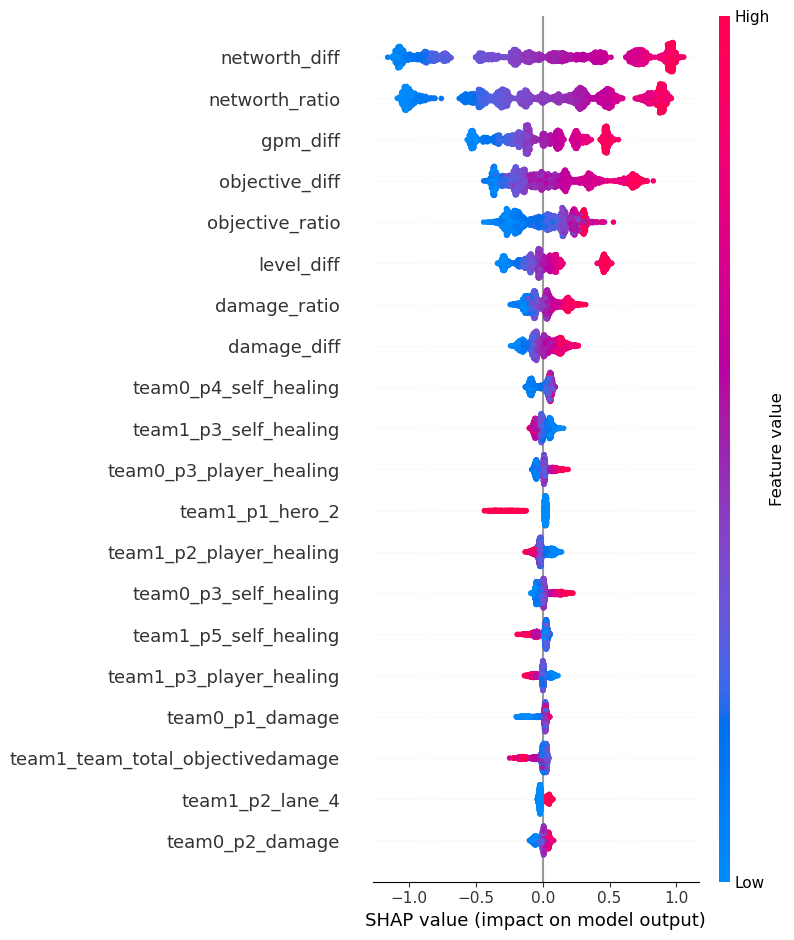

In [ ]:
import shap

explainer = shap.TreeExplainer(model_xgb)

shap_values = (explainer.shap_values( X_test))

shap.summary_plot(shap_values, X_test)

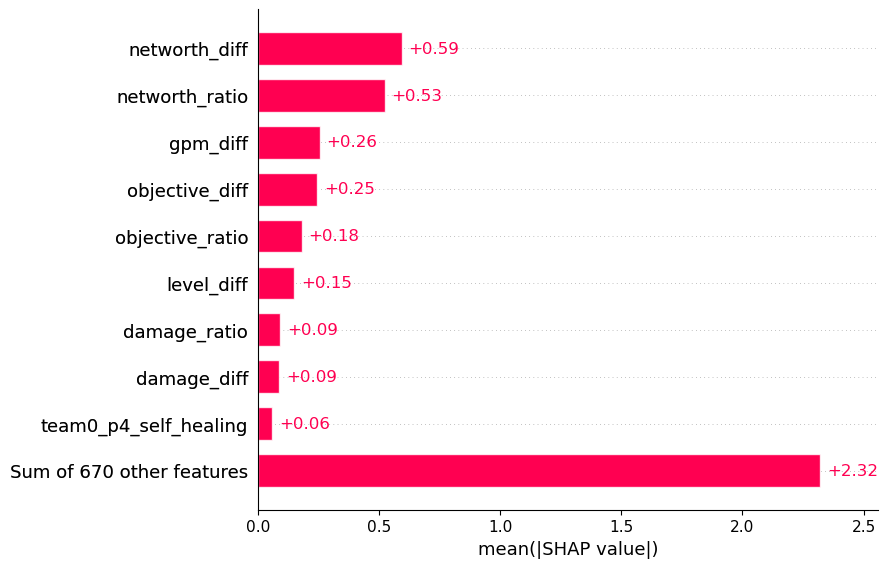

In [ ]:
shap.plots.bar(shap.Explanation(values=shap_values, data=X_test.values, feature_names=X_test.columns))